# Event Impact Modeling (Task 3)

**Author:** Yostina Abera  
**Inputs:** enriched `impact_link` + `event` records · **Engine:** `src/impact_model.py`

Goal: turn the `impact_link` records into a model that predicts how an indicator moves when events occur, summarise them as an **event → indicator association matrix**, and **validate** predictions against observed history. Methodology write-up: `reports/impact_model_methodology.md`.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd, numpy as np
%matplotlib inline
from src import impact_model as im
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

## 1. Understand the impact data
Load impact_links and join to their parent event via `parent_id` to get event name, category and date. The result shows *which event affects which indicator, by how much, in which direction, and with what lag* — plus the unit-aware combination rule and a flag for links that are purely qualitative (no numeric estimate).

In [2]:
il = im.get_impact_table()
show = ['event_name','category','event_date','related_indicator','relationship_type',
        'impact_direction','impact_magnitude','impact_estimate','lag_months',
        'combine','asymptote','is_qualitative','evidence_basis','comparable_country']
il[show].sort_values(['event_name','related_indicator'])

,event_name,category,event_date,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,combine,asymptote,is_qualitative,evidence_basis,comparable_country
17,Banking Business Proclamation No. 1360/2024 (F...,policy,2024-12-17,ACC_OWNERSHIP,indirect,increase,medium,5.0,36.0,additive,5.0,False,literature,Kenya
18,Banking Business Proclamation No. 1360/2024 (F...,policy,2024-12-17,DEP_BORROWED,indirect,increase,medium,8.0,36.0,additive,8.0,False,literature,Kenya
12,EthioPay Instant Payment System Launch,infrastructure,2025-12-18,USG_P2P_COUNT,indirect,increase,medium,15.0,6.0,multiplicative,15.0,False,literature,India
7,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,ACC_OWNERSHIP,enabling,increase,medium,10.0,24.0,additive,10.0,False,literature,India
8,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,GEN_GAP_ACC,indirect,decrease,medium,-5.0,24.0,additive,-5.0,False,literature,India
9,Foreign Exchange Liberalization,policy,2024-07-29,AFF_DATA_INCOME,indirect,increase,high,30.0,3.0,additive,30.0,False,empirical,NaN
10,M-Pesa EthSwitch Integration,partnership,2025-10-27,USG_MPESA_ACTIVE,direct,increase,medium,15.0,3.0,multiplicative,15.0,False,literature,Tanzania
11,M-Pesa EthSwitch Integration,partnership,2025-10-27,USG_P2P_COUNT,direct,increase,medium,10.0,3.0,multiplicative,10.0,False,literature,Tanzania
6,M-Pesa Ethiopia Launch,product_launch,2023-08-01,ACC_MM_ACCOUNT,direct,increase,medium,5.0,6.0,additive,5.0,False,theoretical,NaN
5,M-Pesa Ethiopia Launch,product_launch,2023-08-01,USG_MPESA_USERS,direct,increase,high,NaN,3.0,multiplicative,20.0,True,empirical,NaN


## 2. Functional form — how an effect unfolds over time
**Do effects happen immediately or build gradually?** Gradually. Each link's effect grows along a **half-life saturating ramp**

$$g(\Delta t) = 1 - 0.5^{\,\Delta t / L}, \quad \Delta t \ge 0$$

where `L` = `lag_months`. So `g(L)=0.5` (the lag is the time to reach **half** the full effect), `g(2L)=0.75`, asymptoting to the full magnitude. Direct launches have small `L` (fast), enabling policies have large `L` (slow), so the lag itself encodes how gradual the effect is.

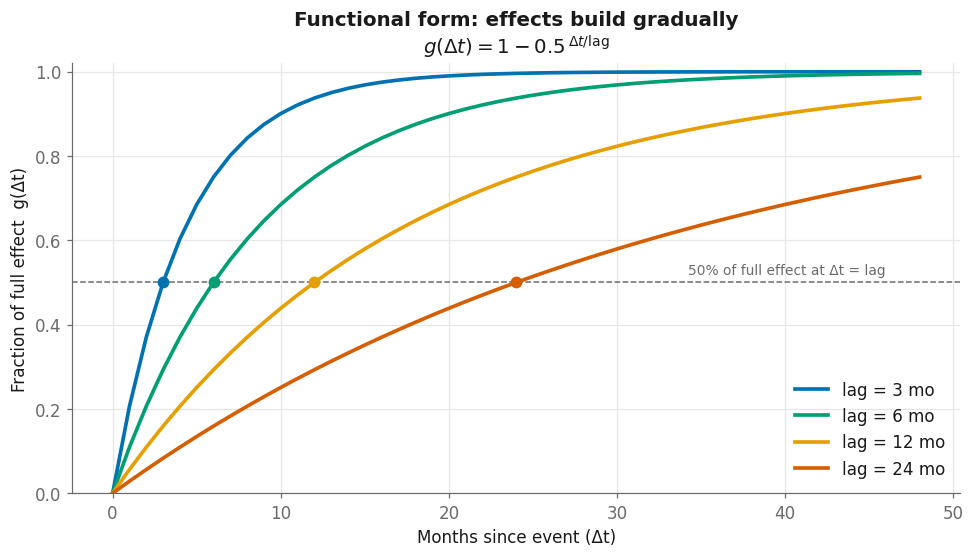

In [3]:
_ = im.fig_effect_curves()

## 3. Representing & combining effects
**How do we combine multiple events?** By indicator unit:
- **Additive** (percentage / gap_pp indicators): effects are in *percentage points* and sum. `level(t) = anchor + Σ Mᵢ·[g(t) − g(anchor)]`
- **Multiplicative** (count / currency indicators): effects are *percent changes* and compound. `level(t) = anchor · Π (1 + (Mᵢ/100)·[g(t) − g(anchor)])`

Effects are measured as an **increment relative to the anchor date**, so an event that began before the anchor is not double-counted. Purely qualitative 'enabling' links (no numeric estimate, e.g. the 2020 directive) enter the *matrix* but are **excluded from the arithmetic** — assigning them a band-midpoint number would be fabrication.

## 4. Event → indicator association matrix
The deliverable: rows = events, columns = key indicators, values = **estimated effect** (pp for percentages, % for counts). Colour encodes the unit-free signed magnitude band so cells are comparable across differing units; `*` marks qualitative (band-derived) cells.

In [4]:
num, ordv = im.build_association_matrix(il)
num.round(0)

related_indicator,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_4G_COV,USG_DIGITAL_PAY,USG_P2P_COUNT,USG_TELEBIRR_USERS,USG_MPESA_USERS,USG_MPESA_ACTIVE,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_MM_SHARE,DEP_BORROWED
event_name,,,,,,,,,,,,
Banking Business Proclamation No. 1360/2024 (Foreign Bank Entry),5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
EthioPay Instant Payment System Launch,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Program Rollout,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.0,NaN,NaN
Foreign Exchange Liberalization,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,NaN,10.0,NaN,NaN,15.0,NaN,NaN,NaN,NaN
M-Pesa Ethiopia Launch,NaN,5.0,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN
NBE Payment Instrument Issuers Directive (ONPS/01/2020),NaN,20.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN
NFIS-II Strategy Launch,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
National Digital Payments Strategy 2021-2024,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


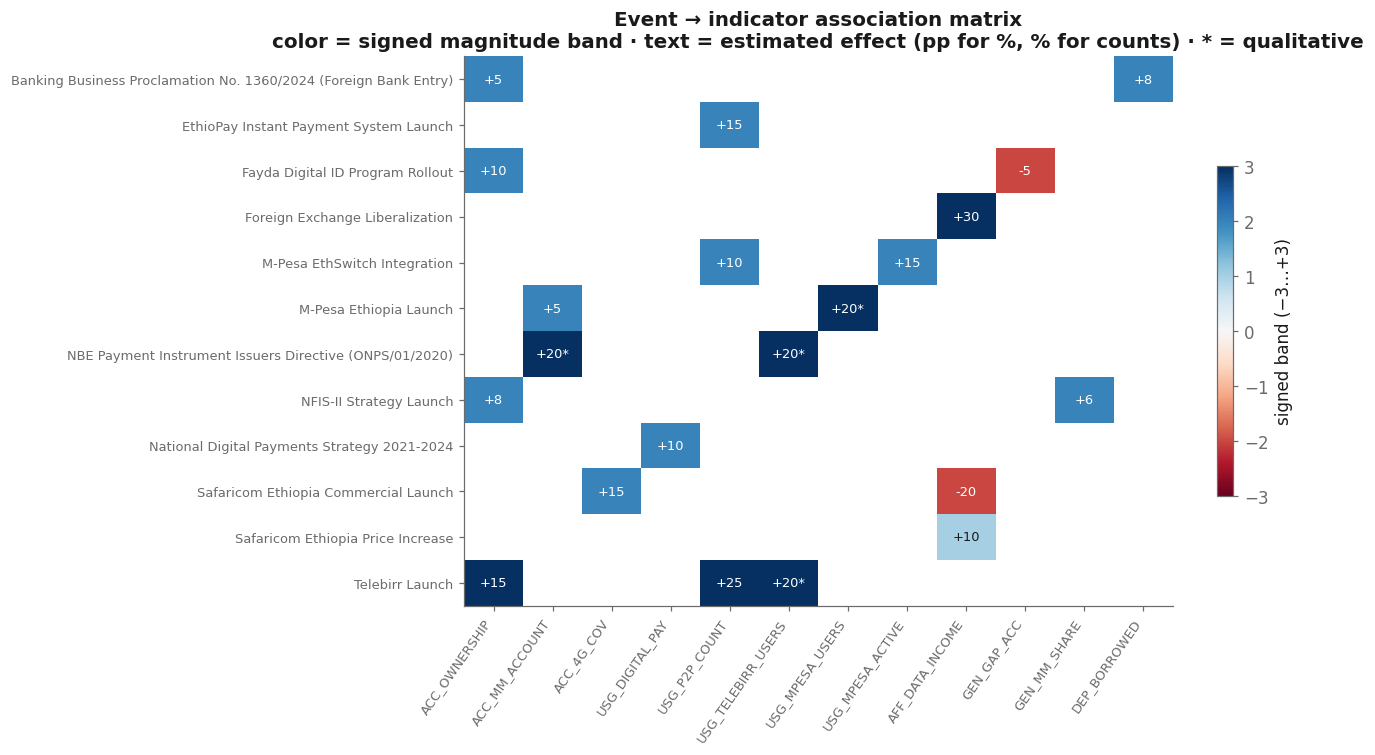

In [5]:
_ = im.fig_association_matrix(il)

## 5. Comparable-country evidence
Where Ethiopian pre/post data is thin, magnitudes are borrowed from documented impacts in similar markets and flagged via `evidence_basis` = `literature` and `comparable_country`. These are the estimates most in need of validation (Section 6).

In [6]:
il[il.evidence_basis=='literature'][['event_name','related_indicator',
     'impact_estimate','lag_months','comparable_country']].sort_values('comparable_country')

,event_name,related_indicator,impact_estimate,lag_months,comparable_country
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,10.0,24.0,India
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,-5.0,24.0,India
12,EthioPay Instant Payment System Launch,USG_P2P_COUNT,15.0,6.0,India
0,Telebirr Launch,ACC_OWNERSHIP,15.0,12.0,Kenya
17,Banking Business Proclamation No. 1360/2024 (F...,ACC_OWNERSHIP,5.0,36.0,Kenya
18,Banking Business Proclamation No. 1360/2024 (F...,DEP_BORROWED,8.0,36.0,Kenya
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,-20.0,12.0,Rwanda
10,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,15.0,3.0,Tanzania
11,M-Pesa EthSwitch Integration,USG_P2P_COUNT,10.0,3.0,Tanzania


## 6. Test the model against historical data
We have two indicators with enough history to check: **ACC_MM_ACCOUNT** and **ACC_OWNERSHIP**. Anchor at the 2021 observation and predict 2024 from the events active in between.

In [7]:
import json
res = im.validate(il)
print(json.dumps(res, indent=2, default=str))

{
  "ACC_OWNERSHIP": {
    "anchor": {
      "date": "2021-12-31",
      "value": 46.0
    },
    "observed": {
      "2024-11-29": 49.0
    },
    "predicted_naive": {
      "2024-11-29": 62.66
    },
    "attenuation": 0.18,
    "predicted_refined": {
      "2024-11-29": 49.0
    }
  },
  "ACC_MM_ACCOUNT": {
    "anchor": {
      "date": "2021-12-31",
      "value": 4.7
    },
    "observed": {
      "2024-11-29": 9.45
    },
    "predicted_naive": {
      "2024-11-29": 8.91
    },
    "attenuation": 1.0
  }
}


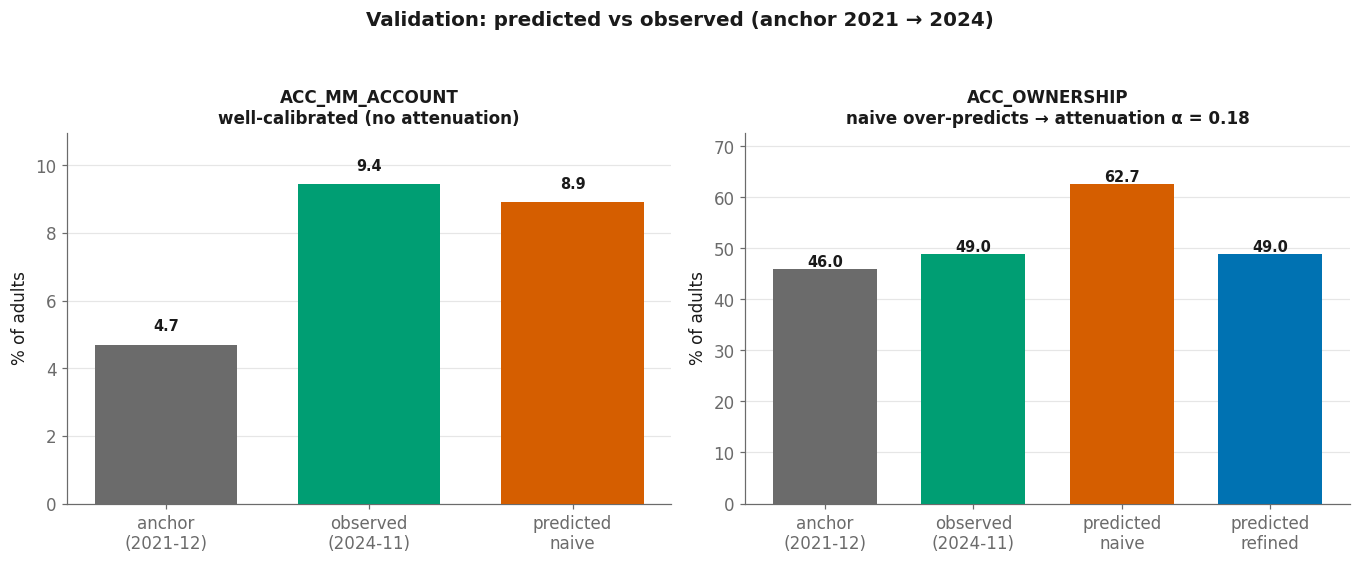

In [8]:
_ = im.fig_validation(il)

### What the validation shows
- **ACC_MM_ACCOUNT — well calibrated.** Predicted **8.9%** vs observed **9.45%** (anchor 4.7% in 2021). The M-Pesa `+5pp` estimate reproduces the observed rise almost exactly; no attenuation needed.
- **ACC_OWNERSHIP — naive model over-predicts badly.** Predicted **62.7%** vs observed **49%**. The account-ownership impacts (Telebirr `+15pp` ex-Kenya, Fayda `+10pp` ex-India, NFIS-II `+8pp`) assume mobile money *creates new account-holders*. In Ethiopia it did not: mobile-money-only users are ~0.5% and bank accounts are already accessible, so registrations mostly digitised the **already-banked** (the EDA paradox). Matching the observed +3pp requires an attenuation of **α ≈ 0.18** — the borrowed impacts realise only ~18% of their nominal effect on *ownership* here.

## 7. Refine the estimates
Adjustments, with reasoning and a confident-vs-uncertain tag:

In [9]:
refine = pd.DataFrame([
 {'indicator':'ACC_OWNERSHIP','change':'apply α≈0.18 to imported ownership impacts',
  'reason':'mobile money digitised existing account-holders, not new ones (registered≠owner)',
  'confidence':'medium — one calibration point (2021→2024)'},
 {'indicator':'ACC_MM_ACCOUNT','change':'keep M-Pesa +5pp as-is',
  'reason':'predicted 8.9% vs observed 9.45% — already accurate',
  'confidence':'high'},
 {'indicator':'ACC_MM_ACCOUNT','change':'add a Telebirr→ACC_MM_ACCOUNT link (future work)',
  'reason':'most 2021→2023 MM-account growth predates M-Pesa (Aug-2023) and is Telebirr-driven; '
           'current fit is right at the endpoint but mis-attributes the driver',
  'confidence':'medium'},
 {'indicator':'USG_TELEBIRR_USERS / USG_MPESA_USERS','change':'model as adoption curves, not % shocks',
  'reason':'these series are created from zero by the launch; a %-change baseline is undefined',
  'confidence':'high (structural)'},
 {'indicator':'AFF_DATA_INCOME','change':'treat as mixed/uncertain sign',
  'reason':'competition lowers cost while FX liberalisation raised it — net effect ambiguous',
  'confidence':'low'},
])
refine

,indicator,change,reason,confidence
0,ACC_OWNERSHIP,apply α≈0.18 to imported ownership impacts,mobile money digitised existing account-holder...,medium — one calibration point (2021→2024)
1,ACC_MM_ACCOUNT,keep M-Pesa +5pp as-is,predicted 8.9% vs observed 9.45% — already acc...,high
2,ACC_MM_ACCOUNT,add a Telebirr→ACC_MM_ACCOUNT link (future work),most 2021→2023 MM-account growth predates M-Pe...,medium
3,USG_TELEBIRR_USERS / USG_MPESA_USERS,"model as adoption curves, not % shocks",these series are created from zero by the laun...,high (structural)
4,AFF_DATA_INCOME,treat as mixed/uncertain sign,competition lowers cost while FX liberalisatio...,low


## 8. Confidence summary
**Confident:** the *direction* of every link; the ACC_MM_ACCOUNT magnitude; the functional form (gradual build); the finding that ownership impacts are over-stated for Ethiopia.  
**Uncertain:** the exact α (single calibration point); count-series magnitudes lacking estimates; long-lag policy effects (NFIS-II, foreign banks) not yet observable; affordability sign.

These calibrated, unit-aware effects and the half-life ramp feed directly into the forecasting phase (Task 4), where Access and Usage are projected as separate targets with event intervention terms and explicit uncertainty bounds.